In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

In [2]:
!pip install pandas nltk textblob scikit-learn matplotlib

In [7]:
df = pd.read_csv("product_feedback.csv")

df.head()

,Feedback
0,The product quality is excellent and I am very...
1,The product is amazing and easy to use
2,Good quality but the price is too high
3,The packaging was damaged when the product arr...
4,I love the design and performance of this product


In [8]:
print(df.shape)

(30, 1)


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Feedback  30 non-null     object
dtypes: object(1)
memory usage: 372.0+ bytes
None


In [10]:
print(df.isnull().sum())

Feedback    0
dtype: int64


In [11]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["Cleaned_Feedback"] = df["Feedback"].apply(preprocess_text)

df.head()

,Feedback,Cleaned_Feedback
0,The product quality is excellent and I am very...,the product quality is excellent and i am very...
1,The product is amazing and easy to use,the product is amazing and easy to use
2,Good quality but the price is too high,good quality but the price is too high
3,The packaging was damaged when the product arr...,the packaging was damaged when the product arr...
4,I love the design and performance of this product,i love the design and performance of this product


In [12]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Feedback"].apply(get_sentiment)

df[["Feedback", "Sentiment"]].head(10)

,Feedback,Sentiment
0,The product quality is excellent and I am very...,Positive
1,The product is amazing and easy to use,Positive
2,Good quality but the price is too high,Positive
3,The packaging was damaged when the product arr...,Neutral
4,I love the design and performance of this product,Positive
5,The product stopped working after two weeks,Neutral
6,The quality is poor and not worth the price,Negative
7,Excellent packaging and fast delivery,Positive
8,The product is easy to use and works perfectly,Positive
9,The instructions are confusing and difficult t...,Negative


In [13]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Positive    17
Negative     7
Neutral      6
Name: count, dtype: int64


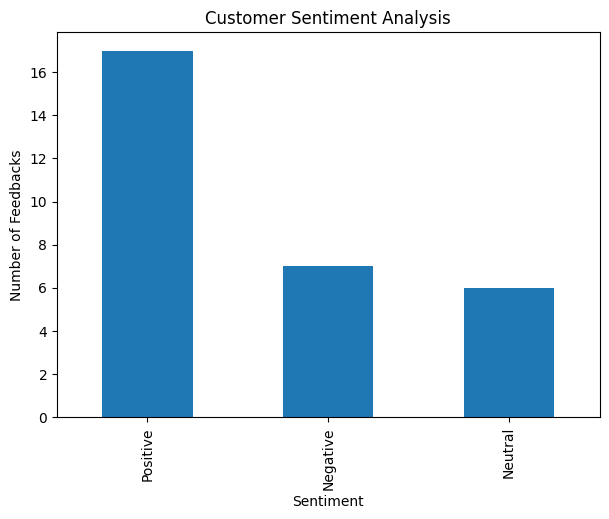

In [14]:
plt.figure(figsize=(7,5))

sentiment_count.plot(kind="bar")

plt.title("Customer Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedbacks")

plt.show()

In [15]:
improvement_keywords = {
    "Quality": ["quality", "poor", "fragile"],
    "Price": ["price", "expensive", "overpriced"],
    "Packaging": ["packaging", "damaged", "broken"],
    "Usability": ["easy", "use", "instructions", "confusing"],
    "Performance": ["performance", "working", "work"],
    "Design": ["design"],
    "Battery": ["battery"]
}

In [16]:
improvement_count = {}

for area, keywords in improvement_keywords.items():
    count = 0

    for text in df["Cleaned_Feedback"]:
        if any(word in text for word in keywords):
            count += 1

    improvement_count[area] = count

print(improvement_count)

{'Quality': 10, 'Price': 5, 'Packaging': 5, 'Usability': 7, 'Performance': 5, 'Design': 3, 'Battery': 1}


In [17]:
improvement_df = pd.DataFrame(
    list(improvement_count.items()),
    columns=["Improvement Area", "Frequency"]
)

print(improvement_df)

  Improvement Area  Frequency
0          Quality         10
1            Price          5
2        Packaging          5
3        Usability          7
4      Performance          5
5           Design          3
6          Battery          1


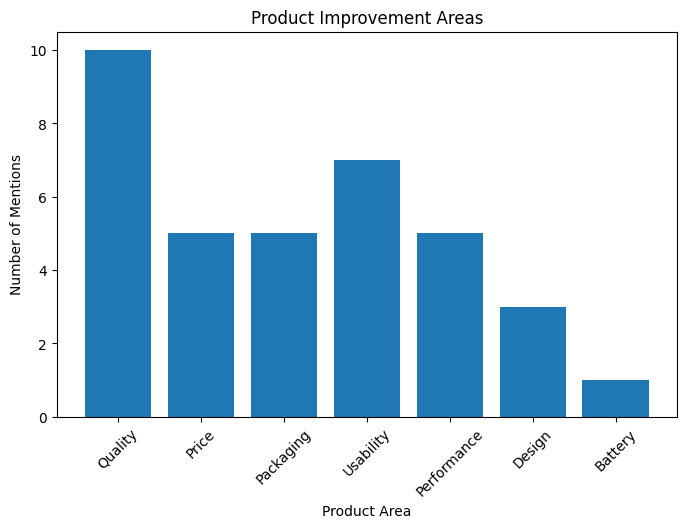

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    improvement_df["Improvement Area"],
    improvement_df["Frequency"]
)

plt.title("Product Improvement Areas")
plt.xlabel("Product Area")
plt.ylabel("Number of Mentions")

plt.xticks(rotation=45)

plt.show()

In [19]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["Cleaned_Feedback"])

word_frequency = pd.DataFrame(
    X.toarray().sum(axis=0),
    index=vectorizer.get_feature_names_out(),
    columns=["Frequency"]
)

word_frequency = word_frequency.sort_values(
    by="Frequency",
    ascending=False
)

print(word_frequency)

              Frequency
product              16
quality               9
excellent             5
packaging             5
use                   3
price                 3
easy                  3
design                3
poor                  3
good                  3
amazing               2
arrived               2
better                2
performance           2
satisfied             2
instructions          2
useful                2
disappointed          1
does                  1
difficult             1


In [20]:
positive = (df["Sentiment"] == "Positive").sum()
negative = (df["Sentiment"] == "Negative").sum()
neutral = (df["Sentiment"] == "Neutral").sum()

print("Positive Feedback:", positive)
print("Negative Feedback:", negative)
print("Neutral Feedback:", neutral)

Positive Feedback: 17
Negative Feedback: 7
Neutral Feedback: 6


In [21]:
top_issue = improvement_df.sort_values(
    by="Frequency",
    ascending=False
).iloc[0]

print(
    "Major Improvement Area:",
    top_issue["Improvement Area"]
)

print(
    "Number of Mentions:",
    top_issue["Frequency"]
)

Major Improvement Area: Quality
Number of Mentions: 10
